In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
train_data = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\House Prices\House data.csv")
train_data.head()
test_data = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\House Prices\test.csv")
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [4]:
train_original=train_data.copy() 
test_original=test_data.copy()

In [5]:
train_data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [6]:
train_data.shape

(1460, 81)

In [7]:
test_data.shape

(1459, 80)

In [8]:
train_data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [9]:
test_data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [10]:
percent_missing = train_data.isnull().sum() * 100 / len(train_data)
percent_missing

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [11]:
del train_data["Alley"]
del train_data["Fence"]
del train_data["MiscFeature"]
del train_data["PoolQC"]

In [12]:
train_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [13]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


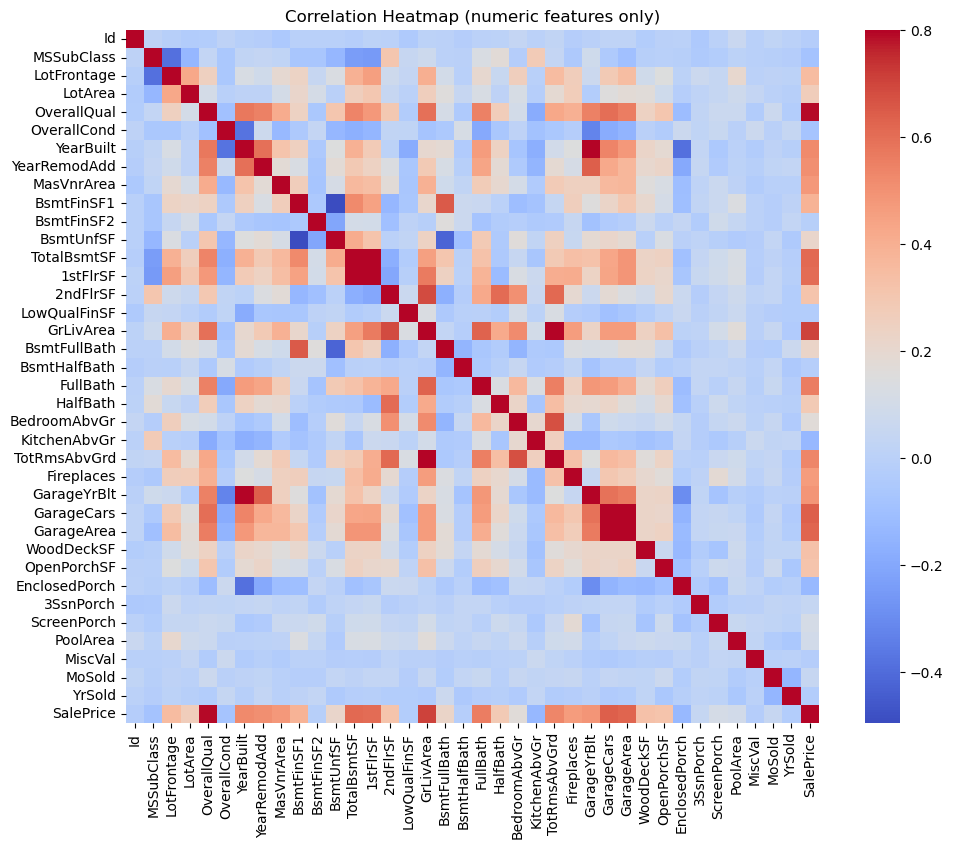

In [17]:
numeric_df = train_data.select_dtypes(include=['int64', 'float64'])

corrmat = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (numeric features only)')
plt.show()

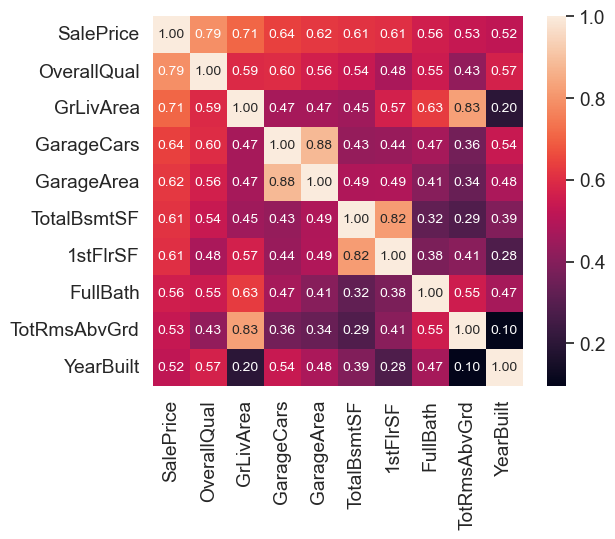

In [18]:
k = 10
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(train_data[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

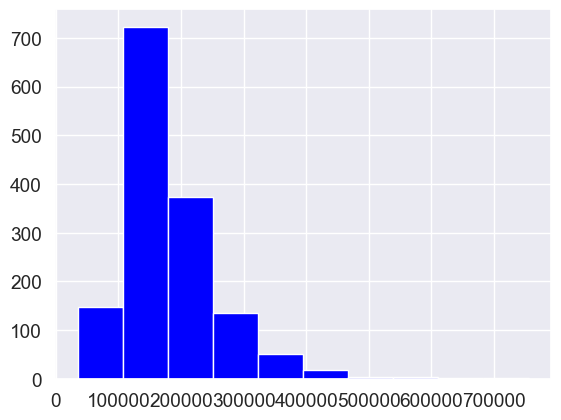

In [19]:
train_data.SalePrice.skew()
plt.hist(train_data.SalePrice, color = "blue")
plt.show()

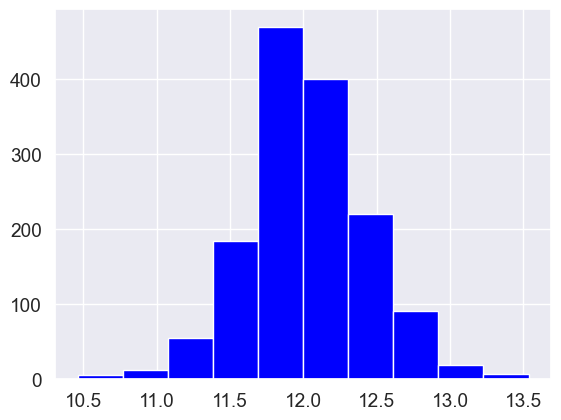

In [20]:
target = np.log(train_data.SalePrice)
target.skew()
plt.hist(target, color = "blue")
plt.show()

In [21]:
most_corr = pd.DataFrame(cols)
most_corr.columns = ['Most Correlated Features']
most_corr

,Most Correlated Features
0,SalePrice
1,OverallQual
2,GrLivArea
3,GarageCars
4,GarageArea
5,TotalBsmtSF
6,1stFlrSF
7,FullBath
8,TotRmsAbvGrd
9,YearBuilt


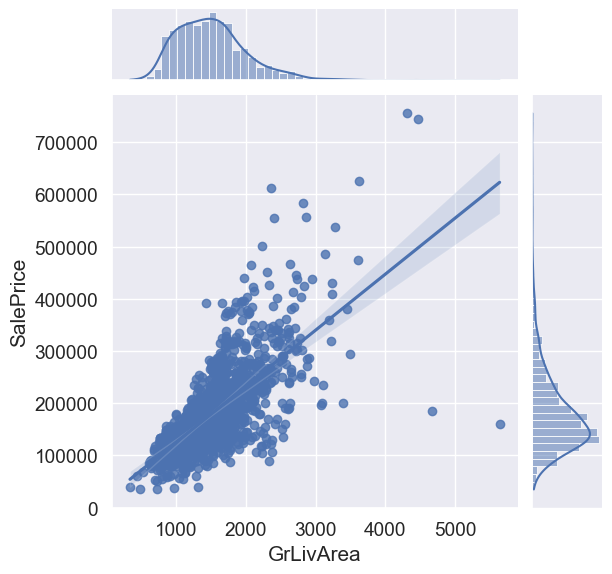

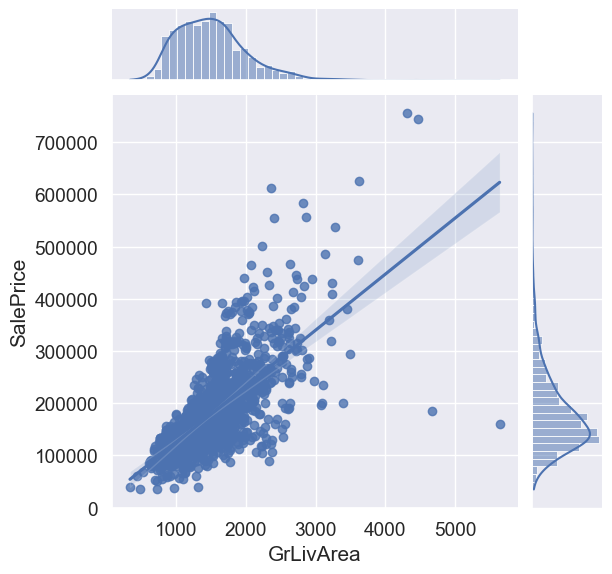

In [23]:
sns.jointplot(x=train_data['GrLivArea'], y=train_data['SalePrice'], kind='reg')
plt.show()

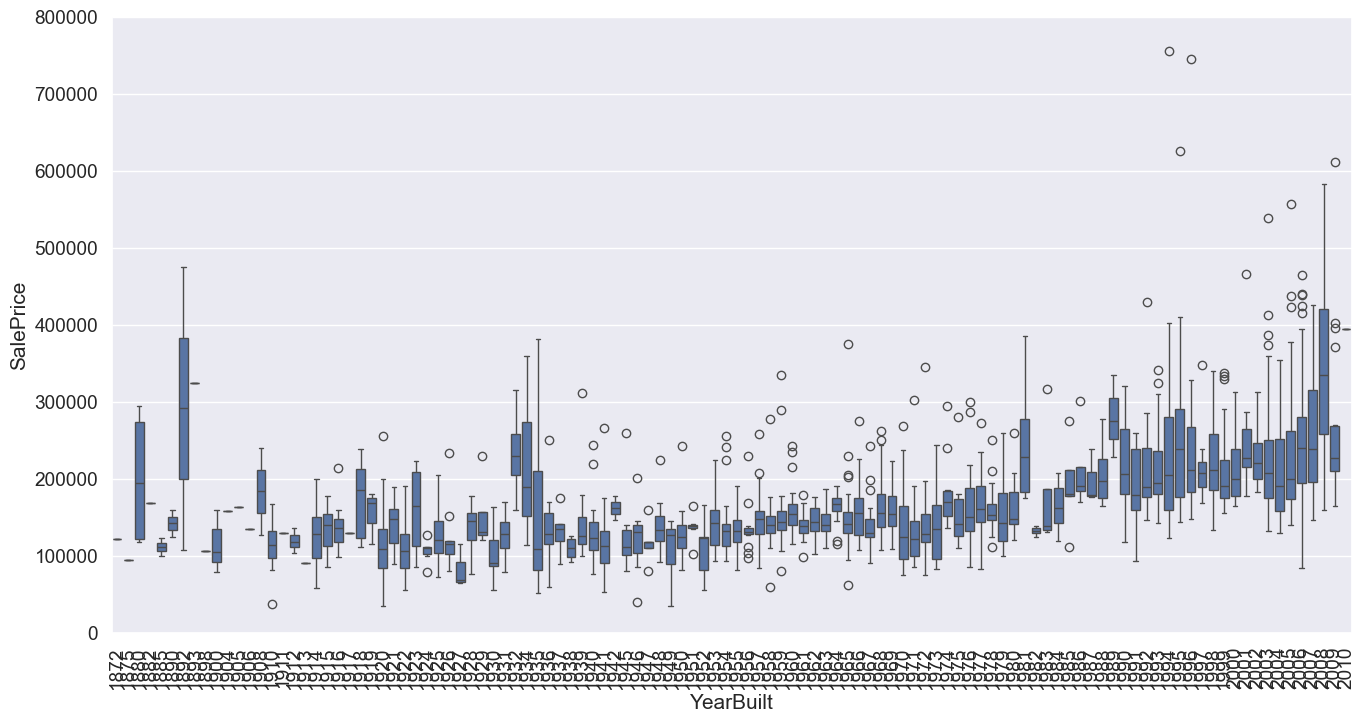

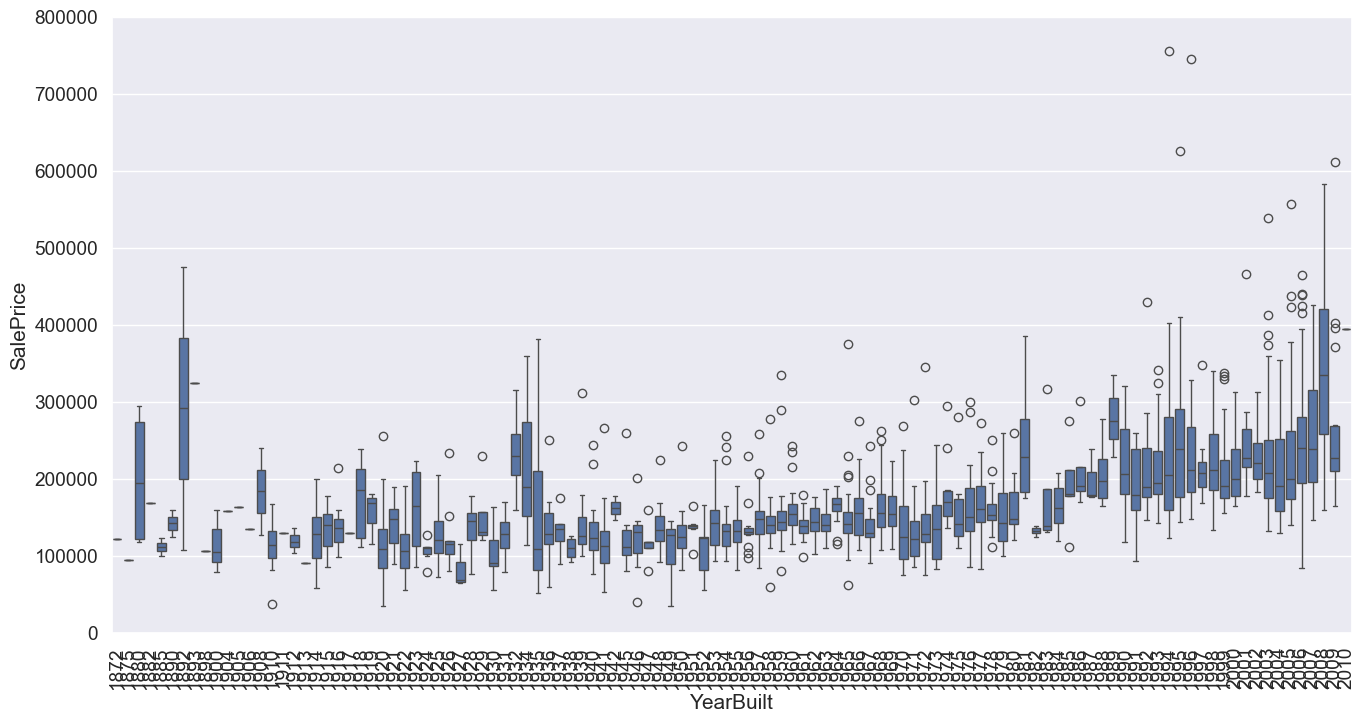

In [25]:
var = 'YearBuilt'
data = pd.concat([train_data['SalePrice'], train_data[var]], axis=1)
f, ax = plt.subplots(figsize=(16, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);
plt.xticks(rotation=90);
plt.show()

In [26]:
numeric_features = train_data.select_dtypes(include=[np.number])
print(numeric_features.dtypes)

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object


In [27]:
corr = numeric_features.corr()
print (corr['SalePrice'].sort_values(ascending=False)[:5], '\n')
print (corr['SalePrice'].sort_values(ascending=False)[-5:])

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
Name: SalePrice, dtype: float64 

YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


In [28]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


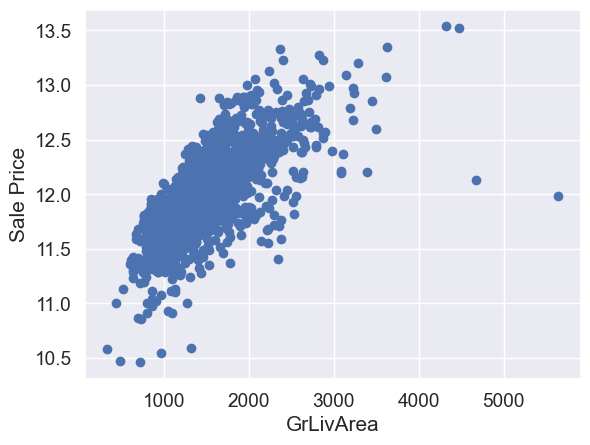

In [29]:
plt.scatter(x=train_data['GrLivArea'],y=target)
plt.ylabel('Sale Price')
plt.xlabel('GrLivArea')
plt.show()

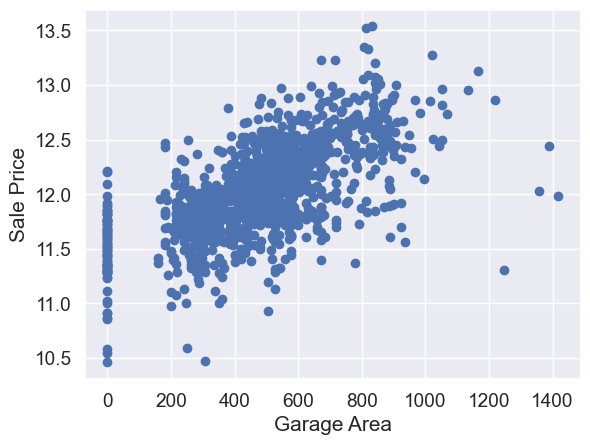

In [30]:
plt.scatter(x=train_data['GarageArea'], y=target)
plt.ylabel('Sale Price')
plt.xlabel('Garage Area')
plt.show()

In [31]:
train_data['FireplaceQu'].fillna(train_data['FireplaceQu'].mode()[0], inplace=True)
train_data['LotFrontage'].fillna(train_data['LotFrontage'].median(), inplace=True)
train_data['GarageType'].fillna(train_data['GarageType'].mode()[0], inplace=True)
train_data['GarageYrBlt'].fillna(train_data['GarageYrBlt'].median(), inplace=True)
train_data['GarageFinish'].fillna(train_data['GarageFinish'].mode()[0], inplace=True)
train_data['GarageQual'].fillna(train_data['GarageQual'].mode()[0], inplace=True)
train_data['GarageCond'].fillna(train_data['GarageCond'].mode()[0], inplace=True)
train_data['MasVnrType'].fillna(train_data['MasVnrType'].mode()[0], inplace=True)
train_data['MasVnrArea'].fillna(train_data['MasVnrArea'].median(), inplace=True)
train_data['BsmtQual'].fillna(train_data['BsmtQual'].mode()[0], inplace=True)


C:\Users\shafaat hussain\AppData\Local\Temp\ipykernel_5068\2684033132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['FireplaceQu'].fillna(train_data['FireplaceQu'].mode()[0], inplace=True)
C:\Users\shafaat hussain\AppData\Local\Temp\ipykernel_5068\2684033132.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

In [32]:
train_data.isnull().sum()*100/len(train_data)

Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
                ... 
MoSold           0.0
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
SalePrice        0.0
Length: 77, dtype: float64

In [33]:
del test_data["Alley"]
del test_data["PoolQC"]
del test_data["Fence"]
del test_data["MiscFeature"]
test_data.shape

(1459, 76)

In [34]:
test_data['LotFrontage'].fillna(test_data['LotFrontage'].median(), inplace=True)
test_data['Exterior1st'].fillna(test_data['Exterior1st'].mode()[0], inplace=True)
test_data['Exterior2nd'].fillna(test_data['Exterior2nd'].mode()[0], inplace=True)
test_data['FireplaceQu'].fillna(test_data['FireplaceQu'].mode()[0], inplace=True)
test_data['MasVnrType'].fillna(test_data['MasVnrType'].mode()[0], inplace=True)
test_data['MasVnrArea'].fillna(test_data['MasVnrArea'].median(), inplace=True)
test_data['GarageType'].fillna(test_data['GarageType'].mode()[0], inplace=True)
test_data['GarageYrBlt'].fillna(test_data['GarageYrBlt'].median(), inplace=True)
test_data['GarageFinish'].fillna(test_data['GarageFinish'].mode()[0], inplace=True)
test_data['GarageQual'].fillna(test_data['GarageQual'].mode()[0], inplace=True)
test_data['GarageCond'].fillna(test_data['GarageCond'].mode()[0], inplace=True)
test_data['MSZoning'].fillna(test_data['MSZoning'].mode()[0], inplace=True)
test_data['Utilities'].fillna(test_data['Utilities'].mode()[0], inplace=True)
test_data['BsmtQual'].fillna(test_data['BsmtQual'].mode()[0], inplace=True)
test_data['BsmtFullBath'].fillna(test_data['BsmtFullBath'].median(), inplace=True)
test_data['BsmtHalfBath'].fillna(test_data['BsmtHalfBath'].median(), inplace=True)
test_data['KitchenQual'].fillna(test_data['KitchenQual'].mode()[0], inplace=True)
test_data['GarageCars'].fillna(test_data['GarageCars'].median(), inplace=True)
test_data['GarageArea'].fillna(test_data['GarageArea'].median(), inplace=True)
test_data['SaleType'].fillna(test_data['SaleType'].mode()[0], inplace=True)
test_data['Functional'].fillna(test_data['Functional'].mode()[0], inplace=True)

C:\Users\shafaat hussain\AppData\Local\Temp\ipykernel_5068\4016163837.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['LotFrontage'].fillna(test_data['LotFrontage'].median(), inplace=True)
C:\Users\shafaat hussain\AppData\Local\Temp\ipykernel_5068\4016163837.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

In [35]:
test_data.isnull().sum()*100/len(test_data)

Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
                ... 
MiscVal          0.0
MoSold           0.0
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
Length: 76, dtype: float64

In [36]:
test_data.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
Length: 76, dtype: object

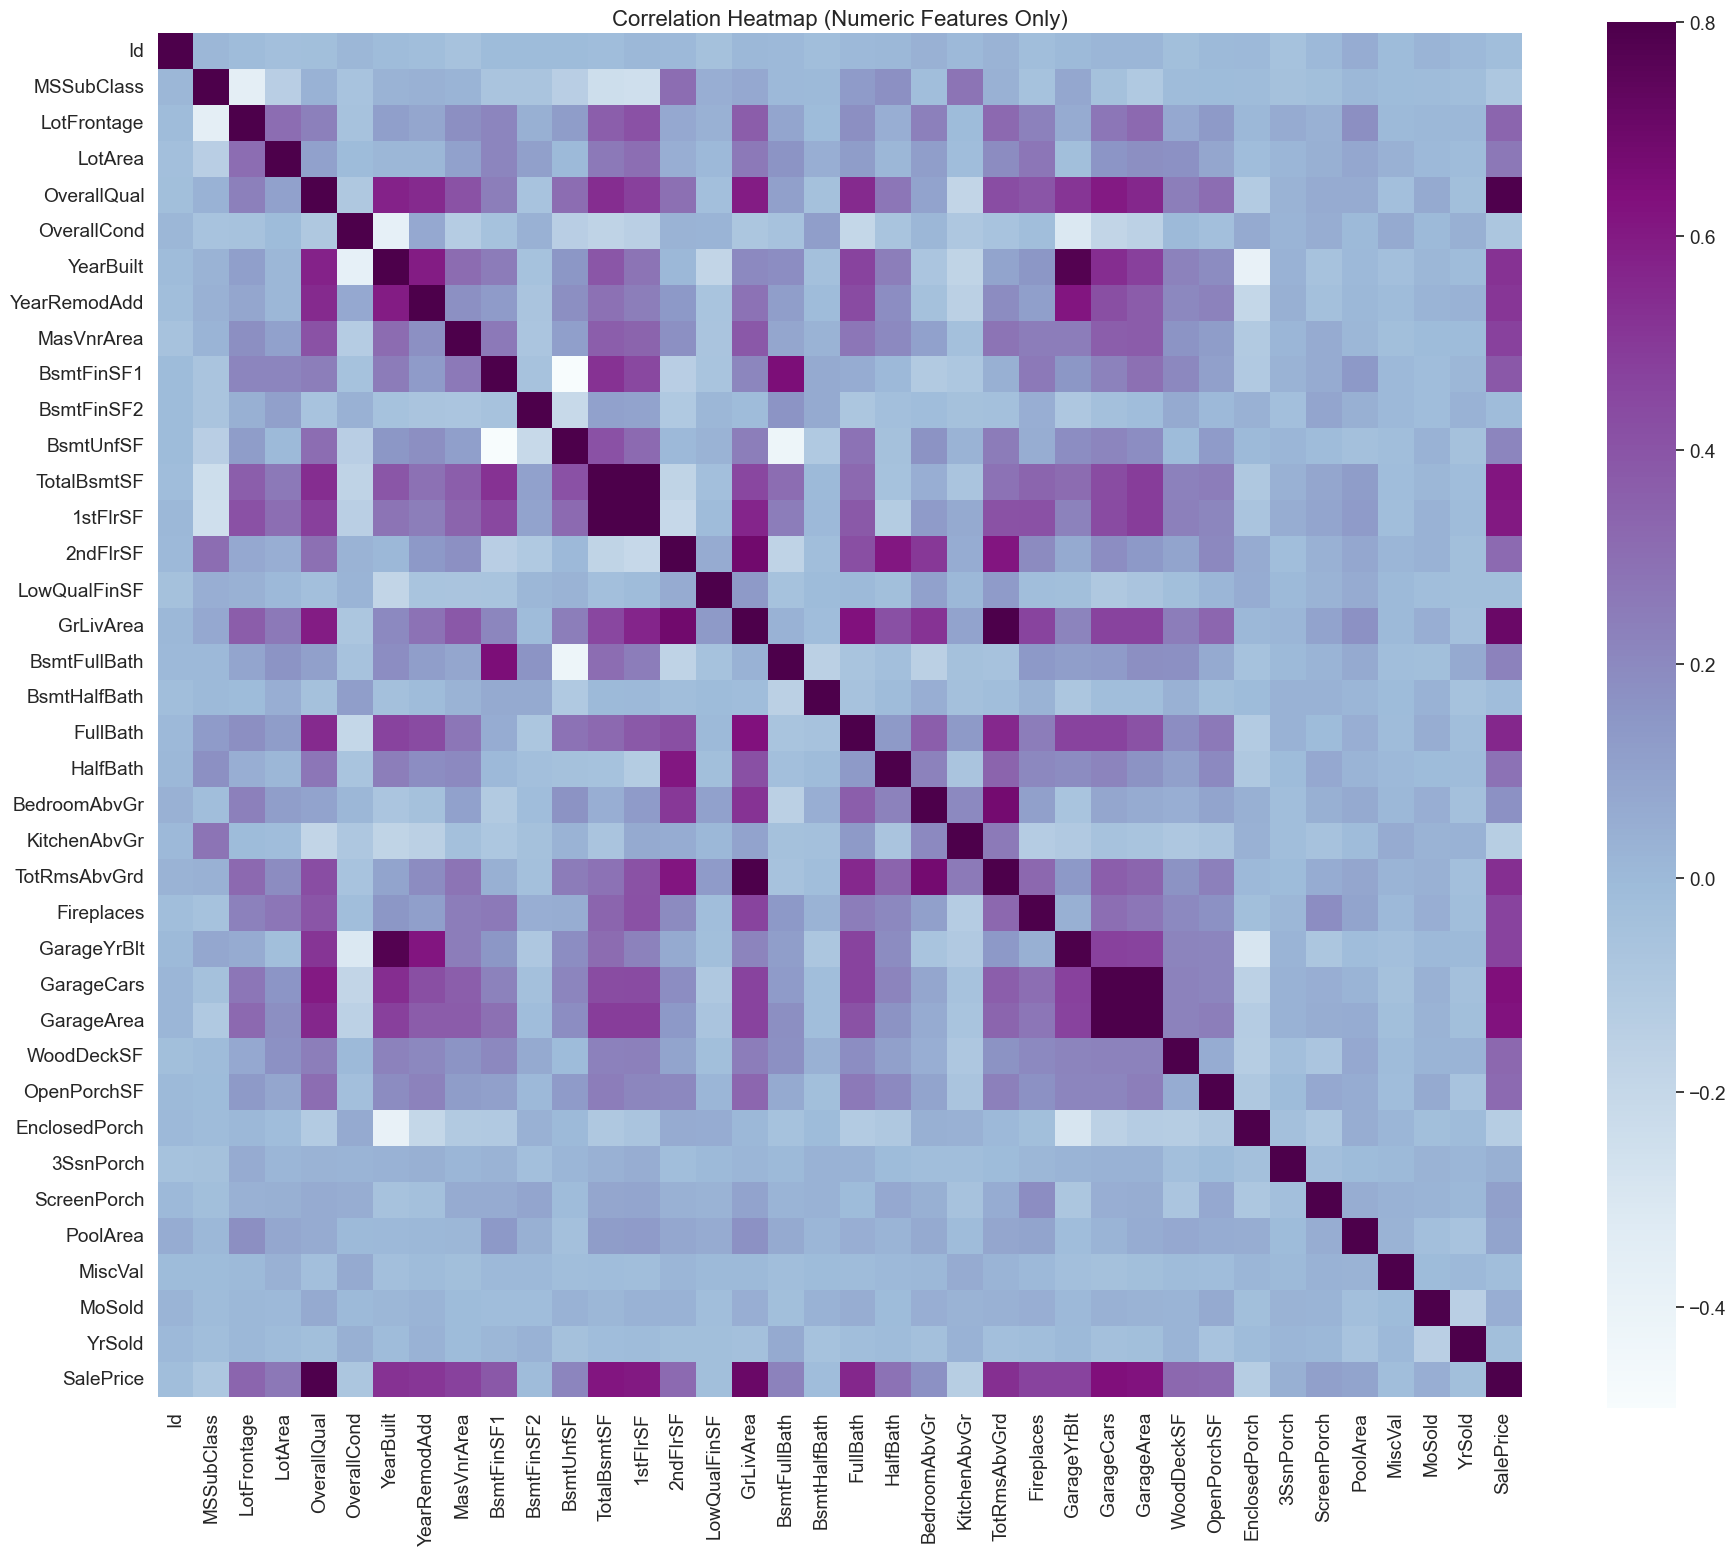

In [39]:
numeric_train = train_data.select_dtypes(include=['int64', 'float64'])

matrix = numeric_train.corr()

plt.figure(figsize=(22, 18))
sns.heatmap(matrix, vmax=.8, square=True, cmap="BuPu", annot=False, cbar=True)
plt.title("Correlation Heatmap (Numeric Features Only)", fontsize=16)
plt.show()

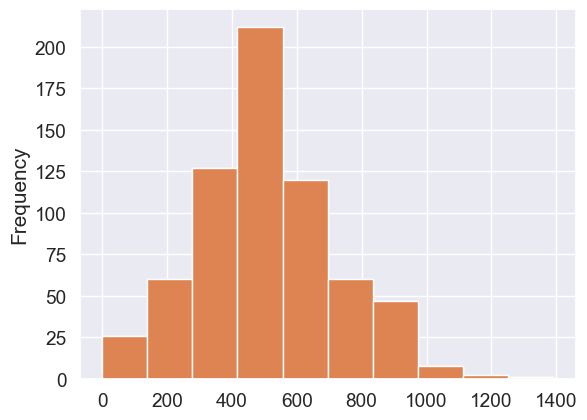

In [41]:
train_data.groupby('SalePrice')['GarageArea'].mean().plot.hist()
plt.show()

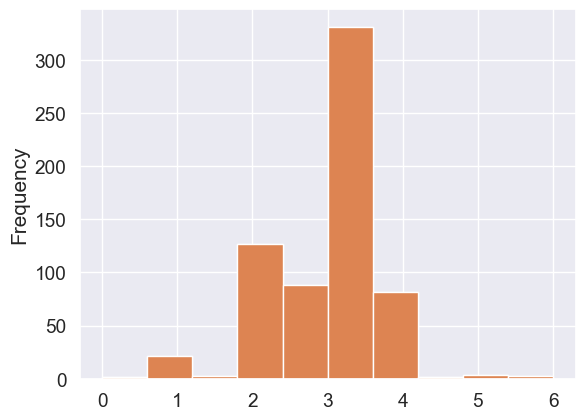

In [43]:
train_data.groupby('SalePrice')['BedroomAbvGr'].mean().plot.hist()
plt.show()

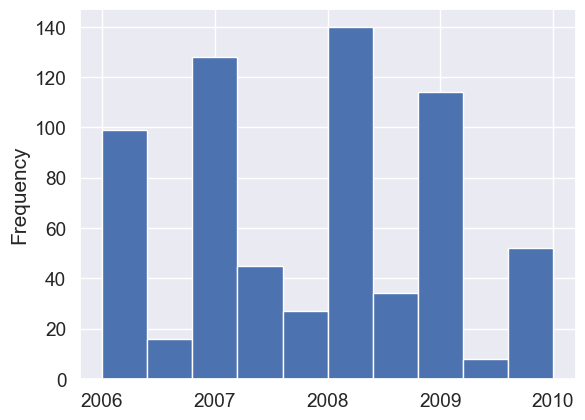

In [44]:
train_data.groupby('SalePrice')['YrSold'].mean().plot.hist()
plt.show()

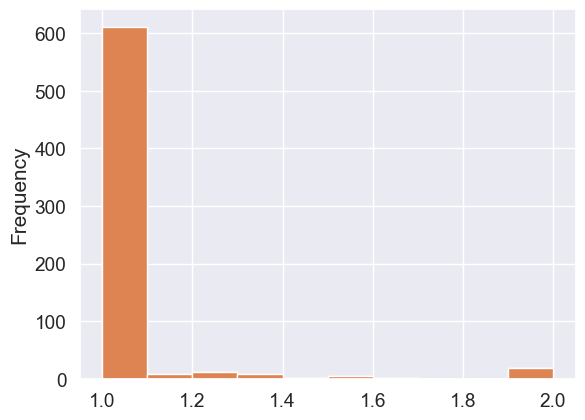

In [46]:
train_data.groupby('SalePrice')['KitchenAbvGr'].mean().plot.hist()
plt.show()

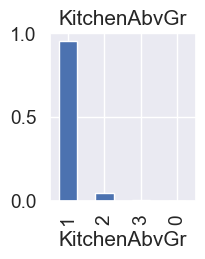

In [47]:
plt.subplot(234) 
train_data['KitchenAbvGr'].value_counts(normalize=True).plot.bar(title= 'KitchenAbvGr') 
plt.show()

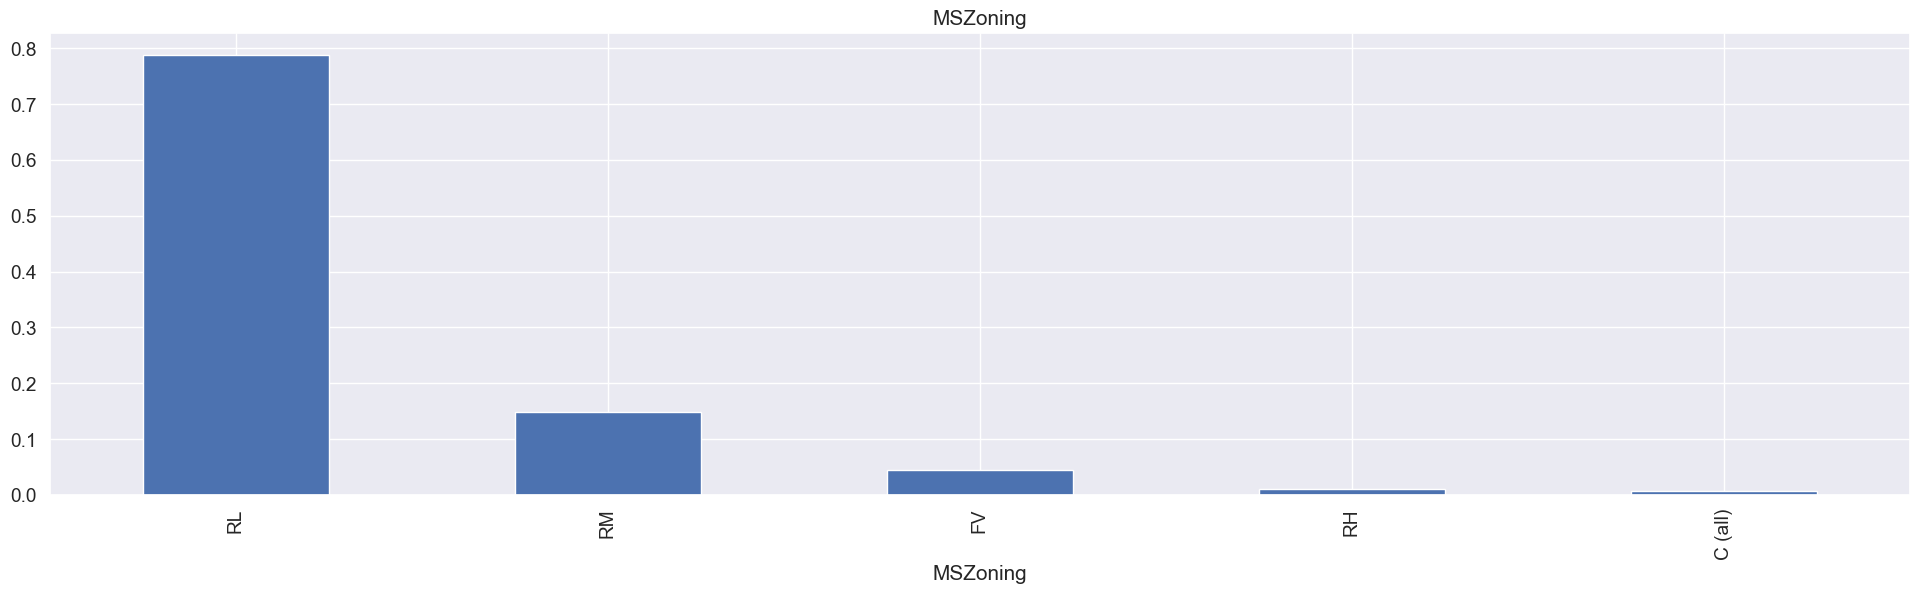

In [48]:
train_data['MSZoning'].value_counts(normalize=True).plot.bar(figsize=(24,6), title= 'MSZoning') 
plt.show()

C:\Users\shafaat hussain\AppData\Local\Temp\ipykernel_5068\1697959886.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['TotalBsmtSF']);


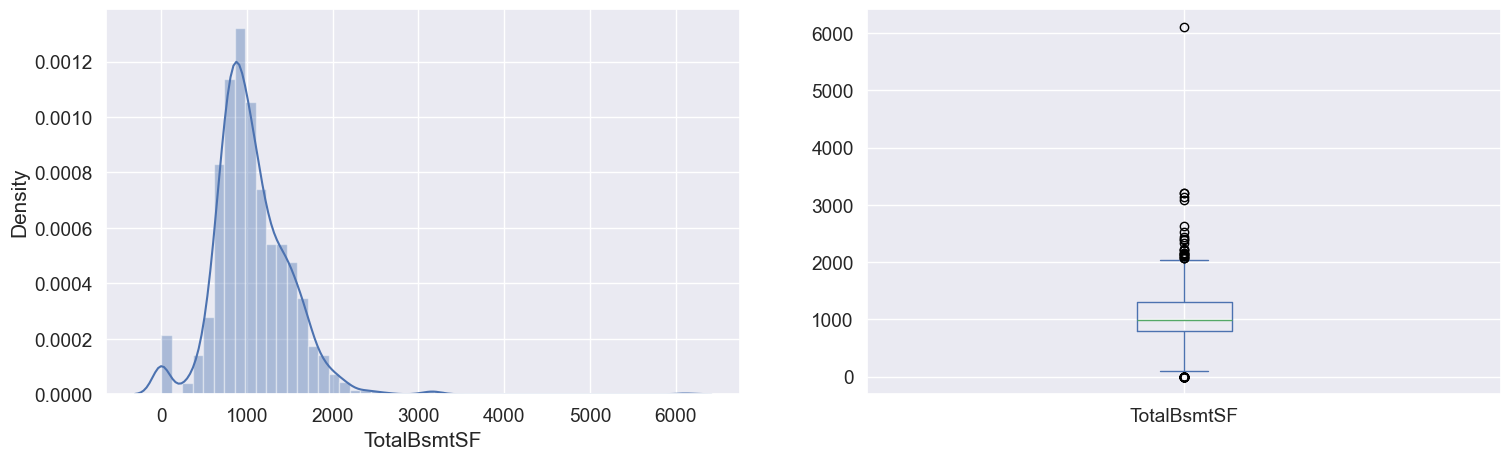

In [49]:
plt.figure(1) 
plt.subplot(121) 
sns.distplot(train_data['TotalBsmtSF']); 
plt.subplot(122) 
train_data['TotalBsmtSF'].plot.box(figsize=(18,5)) 
plt.show()

In [50]:
train=train_data.drop('Id',axis=1)


In [51]:
train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [52]:
from sklearn.preprocessing import LabelEncoder
cols = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 
        'ExterQual', 'ExterCond','HeatingQC', 'KitchenQual', 'BsmtFinType1', 
        'BsmtFinType2', 'Functional', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'CentralAir', 'MSSubClass', 'OverallCond', 
        'YrSold', 'MoSold','SaleType','SaleCondition','Heating','Electrical','GarageType','MSZoning','LandContour','Utilities',
       'LotConfig','Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd',
       'MasVnrType','Foundation')
# Process columns and apply LabelEncoder to categorical features
for c in cols:
    lbl = LabelEncoder()
    lbl.fit(list(train_data[c].values)) 
    train_data[c] = lbl.transform(list(train_data[c].values))

# Check shape        
print('Shape all_data: {}'.format(train_data.shape))

Shape all_data: (1460, 77)


In [53]:
from sklearn.preprocessing import LabelEncoder
cols = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 
        'ExterQual', 'ExterCond','HeatingQC', 'KitchenQual', 'BsmtFinType1', 
        'BsmtFinType2', 'Functional', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'CentralAir', 'MSSubClass', 'OverallCond', 
        'YrSold', 'MoSold','SaleType','SaleCondition','Heating','Electrical','GarageType','MSZoning','LandContour','Utilities',
       'LotConfig','Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd',
       'MasVnrType','Foundation')
# Process columns and apply LabelEncoder to categorical features
for c in cols:
    lbl = LabelEncoder()
    lbl.fit(list(test_data[c].values)) 
    test_data[c] = lbl.transform(list(test_data[c].values))

# Check shape        
print('Shape all_data: {}'.format(test_data.shape))

Shape all_data: (1459, 76)


In [54]:
test_data.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 76, dtype: int64

In [55]:
test_data.isnull().sum()*100/len(test_data)

Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
                ... 
MiscVal          0.0
MoSold           0.0
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
Length: 76, dtype: float64

In [56]:
test_data.head()



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,0,2,80.0,11622,1,3,3,0,4,...,0,0,0,120,0,0,5,4,8,4
1,1462,0,3,81.0,14267,1,0,3,0,0,...,36,0,0,0,0,12500,5,4,8,4
2,1463,5,3,74.0,13830,1,0,3,0,4,...,34,0,0,0,0,0,2,4,8,4
3,1464,5,3,78.0,9978,1,0,3,0,4,...,36,0,0,0,0,0,5,4,8,4
4,1465,11,3,43.0,5005,1,0,1,0,4,...,82,0,0,144,0,0,0,4,8,4


In [57]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,5,3,65.0,8450,1,3,3,0,4,...,0,0,0,0,0,1,2,8,4,208500
1,2,0,3,80.0,9600,1,3,3,0,2,...,0,0,0,0,0,4,1,8,4,181500
2,3,5,3,68.0,11250,1,0,3,0,4,...,0,0,0,0,0,8,2,8,4,223500
3,4,6,3,60.0,9550,1,0,3,0,0,...,272,0,0,0,0,1,0,8,0,140000
4,5,5,3,84.0,14260,1,0,3,0,2,...,0,0,0,0,0,11,2,8,4,250000


In [59]:
y = train_data["SalePrice"]
X = train_data.drop("SalePrice", axis=1)

In [60]:
from sklearn import model_selection
test_size = 0.3
seed = 7
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X,y, test_size=test_size, random_state=seed)

In [61]:
test_data.shape

(1459, 76)

In [62]:
#RandomForest
from sklearn import model_selection
from sklearn.ensemble import RandomForestRegressor
forest_reg =  RandomForestRegressor(n_estimators = 1000, random_state = 42)

In [63]:
forest_reg.fit(X_train,Y_train)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [64]:
forest_pred = forest_reg.predict(X_test)

In [65]:
from sklearn.metrics import mean_squared_error 
from math import sqrt

In [66]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test,forest_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, forest_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, forest_pred)))  

Mean Absolute Error: 17441.59972146119
Mean Squared Error: 903768312.7305994
Root Mean Squared Error: 30062.739607870062


In [67]:
#Linear Regression
from sklearn.linear_model import LinearRegression
lreg = LinearRegression()
model_fit = lreg.fit(X_train,Y_train)
lr_predict = model_fit.predict(X_test)
mse = metrics.mean_squared_error(Y_test,lr_predict)
print("mse value:" ,mse)
rmse = np.sqrt(metrics.mean_squared_error(Y_test,lr_predict))
print("rmse:", rmse)

mse value: 1304597808.2274766
rmse: 36119.2166059492


In [71]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics


ridge_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=0.05))
ridge_model = ridge_pipeline.fit(X_train, Y_train)
ridge_pred = ridge_model.predict(X_test)

mse = metrics.mean_squared_error(Y_test, ridge_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 1304580784.3675354
Root Mean Squared Error: 36118.98094309328


In [73]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics

lasso_pipeline = make_pipeline(StandardScaler(), Lasso(alpha=0.3))
model_lasRig = lasso_pipeline.fit(X_train, Y_train)
lasso_pred = model_lasRig.predict(X_test)

mse = metrics.mean_squared_error(Y_test, lasso_pred)
rmse = np.sqrt(mse)

print("MSE value:", mse)
print("Root Mean Squared Error:", rmse)

MSE value: 1304555480.7994943
Root Mean Squared Error: 36118.63066063682
